In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
df_train = pd.read_parquet("../data/processed/train_test_out_sample_cleaned/idf_vf_train_selected_features.parquet")
df_test = pd.read_parquet("../data/processed/train_test_out_sample_cleaned/idf_vf_test_selected_features.parquet")
df_oos = pd.read_parquet("../data/processed/train_test_out_sample_cleaned/idf_vf_out_of_sample_selected_features.parquet")

In [18]:
# 1. Définition des colonnes à bannir de X
TARGET = 'prix_m2'
cols_to_ban = [
    TARGET,
    'code_departement',
    'ecart_prix_median_pct'
]

# 2. Fonction pour créer X et y 
def prepare_data(df, dataset_name):
    cols_to_drop = [c for c in cols_to_ban if c in df.columns]

    X = df.drop(columns=cols_to_drop)
    y = df[TARGET]

    print(f"[{dataset_name}]")
    print(f" -> Colonnes supprimées : {cols_to_drop}")
    print(f" -> Dimensions X : {X.shape} | y : {y.shape}")
    return X, y

print("--- CRÉATION DES DATASETS ---")

# 3. Application
X_train, y_train = prepare_data(df_train, "TRAIN")
X_test, y_test   = prepare_data(df_test, "TEST")
X_oos, y_oos     = prepare_data(df_oos, "OOS")

--- CRÉATION DES DATASETS ---
[TRAIN]
 -> Colonnes supprimées : ['prix_m2', 'code_departement']
 -> Dimensions X : (507388, 22) | y : (507388,)
[TEST]
 -> Colonnes supprimées : ['prix_m2', 'code_departement']
 -> Dimensions X : (126848, 22) | y : (126848,)
[OOS]
 -> Colonnes supprimées : ['prix_m2', 'code_departement']
 -> Dimensions X : (47768, 22) | y : (47768,)


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_16457/1073631626.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_16457/1073631626.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(


  🌲 PIPELINE RANDOM FOREST : SAMPLING 50K & OPTIMISATION  
Dataset d'entraînement Total : (507388, 22)
Dataset OOS (Validation)     : (47768, 22)

[Sampling] Création de l'échantillon de 50000 lignes...
 -> Optuna travaillera sur : (50000, 22) (au lieu de (507388, 22))

[Optuna] Recherche des hyperparamètres (sur le sample)...


Best trial: 8. Best value: 1571.11: 100%|██████████| 20/20 [09:19<00:00, 28.00s/it]


✅ Optuna RF terminé !
 -> Meilleur RMSE (Sample) : 1571.11
 -> Meilleurs paramètres   : {'n_estimators': 278, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.35739984068330766}

[Final] Entraînement du modèle final sur TOUT le dataset (X_train)...

[Rapport] Comparaison des performances...

  📊 RÉSULTATS COMPARATIFS (RANDOM FOREST)  
Métrique     TRAIN      TEST  OOS (Validation)
    RMSE 1169.8775 1449.3188         1242.6359
     MAE  793.4706  945.6361          848.3910
      R²    0.8654    0.7936            0.8357


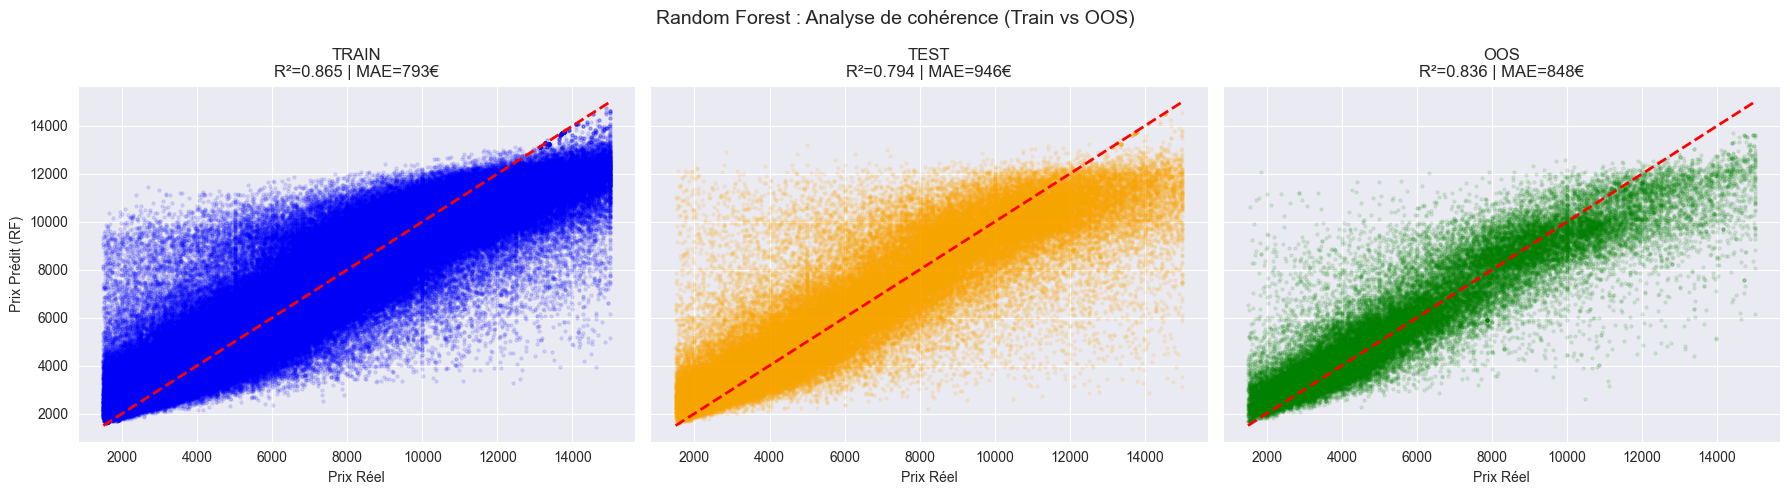


✅  ROBUSTE : Modèle très stable (écart R² = 0.03).


In [19]:
# Configuration
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=======================================================")
print("  PIPELINE RANDOM FOREST : SAMPLING 50K & OPTIMISATION  ")
print("=======================================================")

print(f"Dataset d'entraînement Total : {X_train.shape}")
print(f"Dataset OOS (Validation)     : {X_oos.shape}")


target_sample_size_rf = 50_000
frac_sample_rf = target_sample_size_rf / len(X_train)

if frac_sample_rf > 1.0:
    frac_sample_rf = 1.0

def stratified_sample_rf(X, y, frac, bins=20, seed=42):
    # On recombine temporairement pour stratifier sur le prix
    df_tmp = pd.concat([X, y], axis=1)

    # Création des bins de prix
    df_tmp["_bin"] = pd.qcut(df_tmp[y.name], q=bins, duplicates="drop")

    # Sampling proportionnel dans chaque bin
    df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )

    return df_samp.drop(columns=[y.name, "_bin"]), df_samp[y.name]

print(f"\n[Sampling] Création de l'échantillon de {target_sample_size_rf} lignes...")

# On crée l'échantillon à partir du Train complet
X_sample_rf, y_sample_rf = stratified_sample_rf(X_train, y_train, frac=frac_sample_rf)

print(f" -> Optuna travaillera sur : {X_sample_rf.shape} (au lieu de {X_train.shape})")

# 2. OPTUNA (SUR L'ÉCHANTILLON)

print("\n[Optuna] Recherche des hyperparamètres (sur le sample)...")

def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 10, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_float("max_features", 0.3, 0.9)
    }

    model = RandomForestRegressor(
        n_jobs=-1,
        random_state=42,
        **params
    )

    # Note : Pas besoin de scaler pour RF, mais on gère les NaN
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', model)
    ])

    cv = KFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_validate(
        pipeline, X_sample_rf, y_sample_rf,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'],
        cv=cv, n_jobs=-1
    )

    rmse = np.sqrt(-scores['test_neg_mean_squared_error'].mean())
    mae = -scores['test_neg_mean_absolute_error'].mean()

    trial.set_user_attr("mae", mae)
    return rmse

N_TRIALS_RF = 20
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=N_TRIALS_RF, show_progress_bar=True)

print(f"✅ Optuna RF terminé !")
print(f" -> Meilleur RMSE (Sample) : {study_rf.best_value:.2f}")
print(f" -> Meilleurs paramètres   : {study_rf.best_params}")

best_params_rf = study_rf.best_params


# 3. ENTRAÎNEMENT FINAL (SUR TOUT LE TRAIN)

print("\n[Final] Entraînement du modèle final sur TOUT le dataset (X_train)...")

model_final_rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42,
    verbose=0,
    **best_params_rf
)

# Pipeline final
pipe_final_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', model_final_rf)
])

# Fit sur le dataset COMPLET
pipe_final_rf.fit(X_train, y_train)


# 4. ÉVALUATION COMPARATIVE (TRAIN vs TEST vs OOS)

print("\n[Rapport] Comparaison des performances...")

# Prédictions
y_pred_train = pipe_final_rf.predict(X_train)
y_pred_test  = pipe_final_rf.predict(X_test)
y_pred_oos   = pipe_final_rf.predict(X_oos)

def get_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [rmse, mae, r2]

scores_train = get_metrics(y_train, y_pred_train)
scores_test  = get_metrics(y_test, y_pred_test)
scores_oos   = get_metrics(y_oos, y_pred_oos)

df_results = pd.DataFrame({
    "Métrique": ["RMSE", "MAE", "R²"],
    "TRAIN": scores_train,
    "TEST": scores_test,
    "OOS (Validation)": scores_oos
}).round(4)

print("\n=======================================================")
print("  📊 RÉSULTATS COMPARATIFS (RANDOM FOREST)  ")
print("=======================================================")
print(df_results.to_string(index=False))

#  VISUALISATION
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

datasets = [
    (y_train, y_pred_train, "TRAIN", "blue"),
    (y_test, y_pred_test, "TEST", "orange"),
    (y_oos, y_pred_oos, "OOS", "green")
]

for ax, (y_true, y_pred, title, color) in zip(axes, datasets):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5, c=color)
    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.set_title(f"{title}\nR²={r2:.3f} | MAE={mae:.0f}€")
    ax.set_xlabel("Prix Réel")

axes[0].set_ylabel("Prix Prédit (RF)")
plt.suptitle("Random Forest : Analyse de cohérence (Train vs OOS)", fontsize=14)
plt.tight_layout()
plt.show()

# Diagnostic
gap = scores_train[2] - scores_oos[2]
if gap > 0.15:
    print(f"\n⚠️  ALERTE : Gros écart de R² ({gap:.2f}). Risque d'OVERFITTING important.")
elif gap < 0.05:
    print(f"\n✅  ROBUSTE : Modèle très stable (écart R² = {gap:.2f}).")
else:
    print(f"\nℹ️  NORMAL : Écart classique (écart R² = {gap:.2f}).")

   🚀 PIPELINE XGBOOST : SAMPLING 50K & OPTIMISATION  
Dataset d'entraînement Total : (507388, 22)
Dataset OOS (Validation)     : (47768, 22)

[Sampling] Création de l'échantillon de 50000 lignes...


/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_16457/2784408155.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
/var/folders/jc/g8y4mkqx08vczvr4vtbgbvj40000gn/T/ipykernel_16457/2784408155.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_samp = df_tmp.groupby("_bin", group_keys=False).apply(


 -> Optuna travaillera sur : (50000, 22) (au lieu de (507388, 22))

[Optuna] Recherche des hyperparamètres (sur le sample)...


Best trial: 23. Best value: 1564.38: 100%|██████████| 30/30 [32:03<00:00, 64.12s/it]


✅ Optuna terminé !
 -> Meilleur RMSE (Sample) : 1564.38
 -> Meilleurs paramètres   : {'n_estimators': 631, 'max_depth': 10, 'learning_rate': 0.014992471523201724, 'subsample': 0.7798636060872581, 'colsample_bytree': 0.8499920940075973, 'min_child_weight': 7, 'gamma': 0.45076858305138884, 'reg_alpha': 8.874203461599631, 'reg_lambda': 3.4535428361792357}

[Final] Entraînement du modèle final sur TOUT le dataset (X_train)...

[Rapport] Comparaison des performances...

  📊 RAPPORT DE PERFORMANCES COMPARATIF (XGBOOST)  
                 Métrique     TRAIN      TEST  OOS (Validation)
RMSE (Erreur Quadratique) 1365.1279 1474.0015         1405.3897
     MAE (Erreur Moyenne)  895.6511  955.6446          932.8793
               R² (Score)    0.8168    0.7865            0.7899


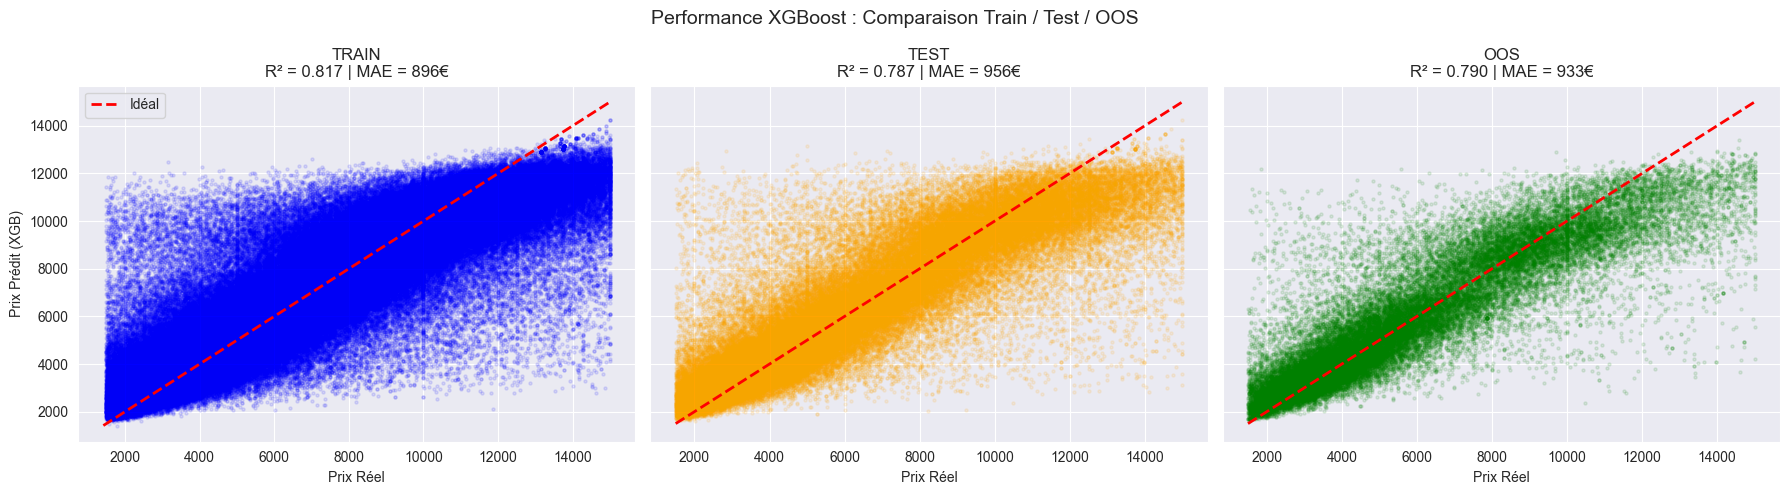


--- DIAGNOSTIC RAPIDE ---
✅  ROBUSTE : Le modèle généralise très bien (écart R² = 0.03).


In [ ]:
# Configuration
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', None)

print("=======================================================")
print("   🚀 PIPELINE XGBOOST : SAMPLING 50K & OPTIMISATION  ")
print("=======================================================")

print(f"Dataset d'entraînement Total : {X_train.shape}")
print(f"Dataset OOS (Validation)     : {X_oos.shape}")


# 1. SAMPLING STRATIFIÉ (Pour accélérer Optuna)

target_sample_size_xgb = 50_000
frac_sample_xgb = target_sample_size_xgb / len(X_train)

if frac_sample_xgb > 1.0:
    frac_sample_xgb = 1.0

def stratified_sample_xgb(X, y, frac, bins=20, seed=42):
    # On recombine temporairement pour stratifier sur le prix
    df_tmp = pd.concat([X, y], axis=1)

    # Création des bins de prix pour bien représenter toutes les gammes de prix
    df_tmp["_bin"] = pd.qcut(df_tmp[y.name], q=bins, duplicates="drop")

    # Sampling proportionnel
    df_samp = df_tmp.groupby("_bin", group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=seed)
    )

    return df_samp.drop(columns=[y.name, "_bin"]), df_samp[y.name]

print(f"\n[Sampling] Création de l'échantillon de {target_sample_size_xgb} lignes...")

# Création du sample XGB
X_sample_xgb, y_sample_xgb = stratified_sample_xgb(X_train, y_train, frac=frac_sample_xgb)

print(f" -> Optuna travaillera sur : {X_sample_xgb.shape} (au lieu de {X_train.shape})")


# 2. OPTIMISATION BAYÉSIENNE (SUR L'ÉCHANTILLON)

print("\n[Optuna] Recherche des hyperparamètres (sur le sample)...")

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
    }

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42,
        verbosity=0,
        **params
    )

    # Cross-Validation (3 plis pour rapidité)
    cv = KFold(n_splits=3, shuffle=True, random_state=42)

    # IMPORTANT : On utilise le SAMPLE ici !
    scores = cross_validate(
        model, X_sample_xgb, y_sample_xgb,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'],
        cv=cv, n_jobs=-1
    )

    rmse = np.sqrt(-scores['test_neg_mean_squared_error'].mean())
    mae = -scores['test_neg_mean_absolute_error'].mean()

    trial.set_user_attr("mae", mae)
    return rmse

N_TRIALS = 30
study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

print("✅ Optuna terminé !")
print(f" -> Meilleur RMSE (Sample) : {study_xgb.best_value:.2f}")
print(f" -> Meilleurs paramètres   : {study_xgb.best_params}")

best_params_xgb = study_xgb.best_params


# 3. ENTRAÎNEMENT FINAL (SUR TOUT LE TRAIN)

print("\n[Final] Entraînement du modèle final sur TOUT le dataset (X_train)...")

model_final_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42,
    **best_params_xgb
)

# Fit sur le dataset COMPLET (pas le sample)
model_final_xgb.fit(X_train, y_train)


# 4. ÉVALUATION COMPARATIVE (TRAIN vs TEST vs OOS)

print("\n[Rapport] Comparaison des performances...")

# Prédictions
y_pred_train = model_final_xgb.predict(X_train)
y_pred_test  = model_final_xgb.predict(X_test)
y_pred_oos   = model_final_xgb.predict(X_oos)

# Fonction de calcul des métriques
def get_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [rmse, mae, r2]

# Calcul
scores_train = get_metrics(y_train, y_pred_train)
scores_test  = get_metrics(y_test, y_pred_test)
scores_oos   = get_metrics(y_oos, y_pred_oos)

# Création du Tableau
df_results = pd.DataFrame({
    "Métrique": ["RMSE (Erreur Quadratique)", "MAE (Erreur Moyenne)", "R² (Score)"],
    "TRAIN": scores_train,
    "TEST": scores_test,
    "OOS (Validation)": scores_oos
}).round(4)

print("\n=======================================================")
print("  📊 RAPPORT DE PERFORMANCES COMPARATIF (XGBOOST)  ")
print("=======================================================")
print(df_results.to_string(index=False))

# VISUALISATION
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

datasets = [
    (y_train, y_pred_train, "TRAIN", "blue"),
    (y_test, y_pred_test, "TEST", "orange"),
    (y_oos, y_pred_oos, "OOS", "green")
]

for ax, (y_true, y_pred, title, color) in zip(axes, datasets):
    ax.scatter(y_true, y_pred, alpha=0.1, s=5, c=color)

    # Ligne idéale y=x
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Idéal")

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    ax.set_title(f"{title}\nR² = {r2:.3f} | MAE = {mae:.0f}€")
    ax.set_xlabel("Prix Réel")
    if title == "TRAIN":
        ax.legend()

axes[0].set_ylabel("Prix Prédit (XGB)")
plt.suptitle("Performance XGBoost : Comparaison Train / Test / OOS", fontsize=14)
plt.tight_layout()
plt.show()

# DIAGNOSTIC
gap = scores_train[2] - scores_oos[2]
print("\n--- DIAGNOSTIC RAPIDE ---")
if gap > 0.15:
    print(f"⚠️  ALERTE OVERFITTING : Le score Train est bien meilleur que OOS (écart R² = {gap:.2f}).")
    print("    Conseil : Augmentez reg_alpha/reg_lambda ou réduisez max_depth.")
elif gap < 0.05:
    print(f"✅  ROBUSTE : Le modèle généralise très bien (écart R² = {gap:.2f}).")
else:
    print(f"ℹ️  NORMAL : Écart standard entre apprentissage et réalité (écart R² = {gap:.2f}).")